# **Lab 2: Regression**

In this lab session, we are given a dataset stored in 'regression-data.txt'. We will develop K Nearest Neighbors (KNNs), linear regression and polynomial regression to fit this dataset. 

**!!! IMPORTANT !!!**
* Please turn OFF any code assistant such as CoPilot;
* You MUST implement KNN, linear regression, and polynomial regression from scratch using the imported libraries below. No additional library is allowed.


In [1]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

### **Load the dataset**
This dataset contains $200$ data points. Each row in the dataset is a data point of the form $[1,~x_1,~x_2,~y]$, where $x_1$ and $x_2$ are two features and $y$ is the target value (i.e., desired output). The first $100$ row will be the training data, next $50$ rows will be the validation data, and the last $50$ rows will be the test data.

Represent the training data as numpy arrays ```Xtrain``` and ```Ytrain```, validation data as ```Xval``` and ```Yval```, and test data as ```Xtest``` and ```Ytest```. The shape of these numpy arrays are 
* ```Xtrain```: (100, 3)
* ```Ytrain```: (100,) not (100, 1)
* ```Xval```: (50, 3)
* ```Yval```: (50,) not (50, 1)
* ```Xtest```: (50, 3)
* ```Ytest```: (50,) not (50, 1)

In [2]:
def read_data(filepath):
    Xtrain, Ytrain, Xval, Yval, Xtest, Ytest = [], [], [], [], [], []
    X, Y = [], []
    
    # extract data from filepath
    """ YOUR CODE HERE """
    with open(filepath, 'r') as file:
        for line in file:
            i, x1, x2, y = map(float, line.split())
            X.append([i, x1, x2])
            Y.append(y)
    Xtrain = X[:100]
    Ytrain = Y[:100]
    Xval   = X[100:150]
    Yval   = Y[100:150]
    Xtest  = X[150:]
    Ytest  = Y[150:]
    
    Xtrain, Ytrain = np.array(Xtrain), np.array(Ytrain)
    Xval, Yval = np.array(Xval), np.array(Yval)
    Xtest, Ytest = np.array(Xtest), np.array(Ytest)
    return Xtrain, Ytrain, Xval, Yval, Xtest, Ytest

In [3]:
filepath = "regression-data.txt"
Xtrain, Ytrain, Xval, Yval, Xtest, Ytest = read_data(filepath)

### **Implement K Nearest Neighbors**

Let's start with implementing a helper function ```euclidean_distance(Xtrain, Xtest)```. It will compute the Euclidean distance between each test point and all training points and save it into an numpy array ```distances``` of shape (100, 50).

In [4]:
import math

def euclidean_distance(Xtrain, Xtest):
    """ YOUR CODE HERE """
    D = []
    for p_i in Xtrain:
        D_i = []
        for p_j in Xtest:
            d = math.sqrt((p_i[1] - p_j[1])**2 + (p_i[2] - p_j[2])**2)
            D_i.append(d)
        D.append(D_i)
    return np.array(D)

Now follow the instructions to implement your KNN regressor.

In [5]:
def knn(Xtrain, Ytrain, Xtest, k):
    # compute Euclidean distances between training data and test data
    distances = euclidean_distance(Xtrain, Xtest)

    # Get the indices of the k nearest neighbors
    knn_indices = []
    """ YOUR CODE HERE """
    for d in distances.T:
        knn_indices.append(d.argsort()[:k])

    # Get the labels of the k nearest neighbors
    knn_labels = Ytrain[knn_indices]

    # Return the weighted average among the k neighbors
    # weights should be the reciprocal of the distance
    """ YOUR CODE HERE """
    knn_label = []
    """
    # Weighted_sum (geometric series) = 1/2 y1 + 1/4 y2 + ... + 1/2**k yk 
    for labels in knn_labels:
        wsum = 0
        for i in range(k):
            wsum += labels[i]/(2**(i+1))
        label = wsum * 2**k / (2**k-1)
        knn_label.append(label)
    """
    # Distance-weighted KNN [https://youtu.be/UAIIW3Bs5HE?feature=shared&t=579]
    for i in range(len(knn_labels)):
        d_k = [distances[knn_indices[i][j]][i] for j in range(k)]   # distances of nearest-k
        w_k = [1/d for d in d_k]                                    # weights based on distance
        w_label = [knn_labels[i][j]*w_k[j] for j in range(k)]       # weighted labels
        label = sum(w_label) / sum(w_k)
        knn_label.append(label)
     
    return knn_label

Once we get the predictions, we calculate the mean squared error between predictions and ```Ytest```.

In [6]:
# get predictions
predictions = knn(Xtrain, Ytrain, Xtest, 5)

# helper function to calculate mean squared error
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# calculate mean squared error
print("Mean Squared Error:", mean_squared_error(Ytest, predictions))

Mean Squared Error: 1.053437086284636


However, it is hard to know the value of ```k``` that could achieve smallest mean squared error on test data. Thus, we will apply the so-called **elbow method** to find the optimal value ```k```.

The elbow method runs like this:
1. Iterate over a list of ```k``` values;
2. For each ```k```, calculate the error (i.e., mean squared error in our case);
3. Find ```k``` such that increasing or decreasing it will cause the error (e.g., mean squared error) to increase

when you draw a curve of ```k``` vs. cost, you will find that the curve actually looks like an elbow -- that's why it is called the **elbow** method.

In [7]:
k_values = [1, 3, 5, 7, 9]
costs = []

# Now iterate your knn over the k_values and save the mean squared errors into costs
""" YOUR CODE HERE """
for k in k_values:
    predictions = knn(Xtrain, Ytrain, Xtest, k)
    costs.append(mean_squared_error(Ytest, predictions))

We will draw a line of ```k``` vs. costs to help us visualize the change in costs and determine the best ```k``` value.

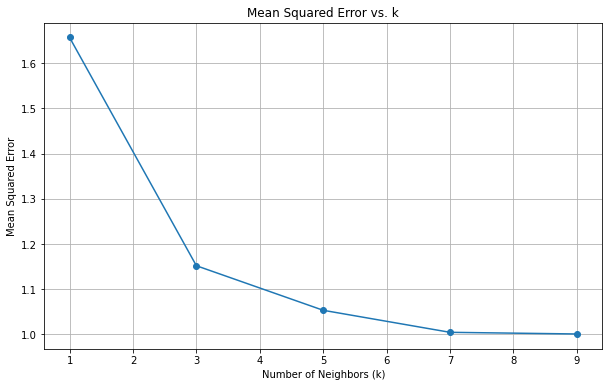

[1.6567479266436778,
 1.1519591067892032,
 1.053437086284636,
 1.0047015946042777,
 1.0010533003276416]

In [8]:
def draw_costs_vs_k(k_values, costs):
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, costs, marker='o')
    plt.title('Mean Squared Error vs. k')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Mean Squared Error')
    plt.grid()
    plt.show()

draw_costs_vs_k(k_values, costs)
costs

***QUESTION***: From the figure drawn by running the code above, could you (1) identify what the best ```k``` value is? If yes, what is the value of ```k``` with the lowest cost? Write your answers in the Markdown cell below.

***Answer:*** <font color='blue'>The best $k$ value is 9, it gives the lowest cost. But, with $k = 7$ we got a slightly higher cost (0.4%) but with the advantage of slightly faster computation. So, in order to choose the $k$ value we must balance the accuracy vs performance. Especially if we deal with a larger dataset, a little drop in accuracy is reasonable for a faster computation.</font>

### **Implement linear regression**

Now we change our regressor from KNN to linear regression. Follow the instructions below to implement linear regression.

$f(x) = w^T x$

where $w[0]$ is the weight for the first column in our dataset $x[0] = 1$.

Linear regression that optimizes the sum-of-square error has a closed-form solution of the optimal $w$, known as the normal equation. Now calculate the optimal weight w using normal equation and (```Xtrain```, ```Ytrain```).

In [9]:
def normal_equation(Xtrain, Ytrain):
    """ YOUR CODE HERE """
    # w = (XT.X)^-1.XT.Y
    return np.linalg.inv(Xtrain.T.dot(Xtrain)).dot(Xtrain.T).dot(Ytrain)

Once we have the optimal weight, we can use it make predictions on ```Xtest``` and calculate its mean squared error compared to ```Ytest```.

In [10]:
w_best = normal_equation(Xtrain, Ytrain)
print("Mean Squared Error:", mean_squared_error(Ytest, Xtest.dot(w_best)))

Mean Squared Error: 0.7194635198603682


***Your submission will be graded based on the mean squared error you got by running the code above.***

### **Implement polynomial regression**

Sometimes we need a higher order model to more accurately fit the data. To implement polynomial regression, we will first implement a function ```polynomial_feature_transformation``` which takes ```Xtrain``` as input and transforms it into ```XtrainPoly```. Specifically, for our data with features $$[1, x_1, x_2],$$ we will transform it to $$[1, x_1, x_2, x_1 x_2, x_1^2, x_2^2].$$

In [11]:
def polynomial_features(X):
    """ YOUR CODE HERE """
    X1X2 = X[:, 1] * X[:, 2]
    X1X1 = X[:, 1] * X[:, 1]
    X2X2 = X[:, 2] * X[:, 2]
    XPoly = np.column_stack((X, X1X2, X1X1, X2X2))
    return XPoly

Similarly, once we have the transformed features ```XtrainPoly```, we will use normal equation to compute the optimal weight ```w_best``` and report the mean squared error on test data (```Xtest```, ```Ytest```).

In [12]:
XtrainPoly = polynomial_features(Xtrain)
w_best = normal_equation(XtrainPoly, Ytrain)
XtestPoly = polynomial_features(Xtest)
print("Mean Squared Error:", mean_squared_error(Ytest, XtestPoly.dot(w_best)))

Mean Squared Error: 0.7525116839329294


***Your submission will be graded based on the mean squared error you got by running the code above.***